# Calibrated CATE estimation and effect analysis

Loads the two calibrated per-arm pipelines saved by
`04_fit_calibrated_models.ipynb` and estimates the Conditional Average Treatment Effect

$$\mathrm{CATE}(x) = P(\text{event}\mid \text{lDAPT}, x) - P(\text{event}\mid \text{sDAPT}, x)$$

for every patient and every endpoint, then visualises the distributions.

**Sign convention** (all endpoints are *adverse* events): `CATE < 0` → lDAPT lowers the
risk (**lDAPT better**); `CATE > 0` → **sDAPT better**.

In [1]:
import os
import sys
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from thesis_utils import predict_proba_matrix

DATA_DIR = os.path.normpath(os.path.join(os.getcwd(), '..', '..', 'data'))
MODELS_DIR = os.path.normpath(os.path.join(os.getcwd(), '..', 'models'))

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)

import warnings
warnings.filterwarnings('ignore')

# Plot layout: target panels per row (2 or 3 keeps each panel readable).
NCOLS = 2

## Load data and the calibrated per-arm models

The feature matrix is rebuilt exactly as in the fit notebook (same leaky-column drop and
numeric selection) so the column order matches what the pipelines were fit on. The two
calibrated models are auto-detected by their `lDAPT` / `sDAPT` suffix.

In [2]:
X = pd.read_parquet(os.path.join(DATA_DIR, 'X_features.parquet'))
y_df = pd.read_parquet(os.path.join(DATA_DIR, 'y_targets.parquet'))

TARGETS = [
    'cec_barc235_335d',
    'cec_cvdeath_335d',
    'cec_mi_335d',
    'cec_stroke_335d',
    'cec_bleed_335d',
]
TARGET_LABELS = ['barc_235', 'death', 'mi', 'stroke', 'bleed']
y_df = y_df[TARGETS]

LEAKY_COLS = ['fup_other', 'fup_nitrates', 'fup_insulin']
X_num = (X.drop(columns=LEAKY_COLS, errors='ignore')
           .select_dtypes(include=[np.number]))

SAVE_DIR = os.path.join(MODELS_DIR, 'T-learner', 'GB')


def load_arm(suffix):
    matches = sorted(glob.glob(os.path.join(SAVE_DIR, f'*_{suffix}.joblib')))
    if not matches:
        raise FileNotFoundError(
            f'No calibrated model for {suffix} in {SAVE_DIR}; '
            'run 04_fit_calibrated_models.ipynb first.')
    return joblib.load(matches[-1]), os.path.basename(matches[-1])


pipe_l, name_l = load_arm('lDAPT')   # prolonged DAPT
pipe_s, name_s = load_arm('sDAPT')   # abbreviated DAPT
print(f'lDAPT model: {name_l}')
print(f'sDAPT model: {name_s}')
print(f'Patients: {len(X_num)}, features: {X_num.shape[1]}')

lDAPT model: GradientBoosting_calibrated_lDAPT.joblib
sDAPT model: GradientBoosting_calibrated_sDAPT.joblib
Patients: 4579, features: 60


## Estimate CATE on the full cohort

For every patient, predict the calibrated event risk under **both** arms (counterfactual
for the arm they were not assigned) and difference them. `predict_proba_matrix` returns an
`(n_patients, n_targets)` matrix, reusing each arm's own fitted imputer/scaler.

In [3]:
risk_l = predict_proba_matrix(pipe_l, X_num)   # P(event | lDAPT)
risk_s = predict_proba_matrix(pipe_s, X_num)   # P(event | sDAPT)

cate = pd.DataFrame(risk_l - risk_s, columns=TARGET_LABELS, index=X_num.index)

summary = pd.DataFrame({
    'mean_CATE': cate.mean(),
    'std_CATE': cate.std(),
    'pct_lDAPT_better': (cate < 0).mean() * 100,   # CATE<0 -> lower risk on lDAPT
    'pct_sDAPT_better': (cate > 0).mean() * 100,
})
print('CATE summary')
summary.round(4)

CATE summary


,mean_CATE,std_CATE,pct_lDAPT_better,pct_sDAPT_better
barc_235,0.036,0.025,6.442,93.558
death,0.005,0.021,21.402,78.598
mi,-0.002,0.024,76.720,23.280
stroke,0.005,0.007,2.249,97.751
bleed,0.051,0.031,4.149,95.851


## Is the heterogeneity real? — RATE / BLP / calibration

The CATE table above (and the distributions below) show *spread*, but a T-learner builds the
CATE as the **difference of two outcome models**, so when each model discriminates only
modestly (AUROC ≈ 0.6 on the bleeding endpoints) much of that spread can be the two models'
noise rather than real treatment-effect heterogeneity. This section tests whether ranking
patients by predicted CATE tracks **real** effect differences, using the *same* doubly-robust
protocol applied to the causal forest in
`../causal_forest/07_causal_forest_analysis.ipynb` (`econml.validate.DRTester`) — so the two
meta-learners are judged on one common metric:

- **BLP slope** — doubly-robust effect score regressed on the predicted CATE. Significantly
  positive ⇒ real signal; ≈ 0 or negative ⇒ the ranking carries no usable heterogeneity.
- **RATE (AUTOC)** and **QINI** — gain from treating the highest-CATE patients first.
- **Calibration R²** — agreement between predicted and realised group effects.

Each arm is refit on a 70% training split and the CATE is validated out-of-sample on the
held-out 30%. Treatment is randomised, so the propensity is the known constant assignment
probability (`DummyClassifier(strategy='prior')`).

> ⚠️ Compute-heavy: refits both calibrated arm models on the training split.


T-learner heterogeneity validation on held-out 30% (positive estimate with small p ==> real, usable heterogeneity)
          BLP_slope  BLP_p  RATE_AUTOC  AUTOC_p   QINI  QINI_p  cal_R2
endpoint                                                              
barc_235     -0.062  0.921       0.009    0.232  0.001   0.381  -0.648
death         0.725  0.039       0.005    0.251  0.001   0.389  -0.303
mi           -0.053  0.877      -0.006    0.261 -0.001   0.373  -0.766
stroke       -0.228  0.621      -0.001    0.447 -0.000   0.479  -1.128
bleed        -0.460  0.362      -0.000    0.498 -0.002   0.341  -0.370


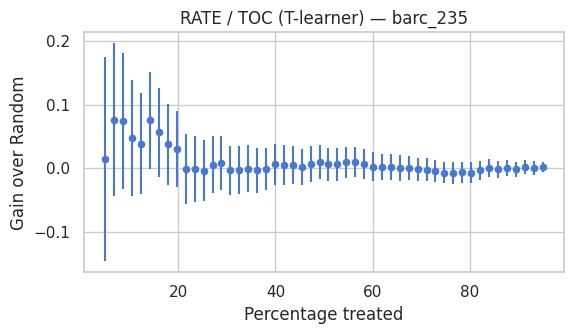

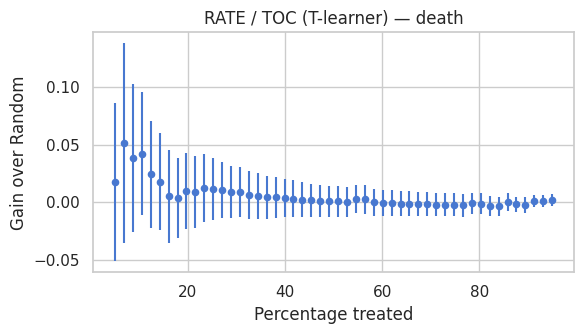

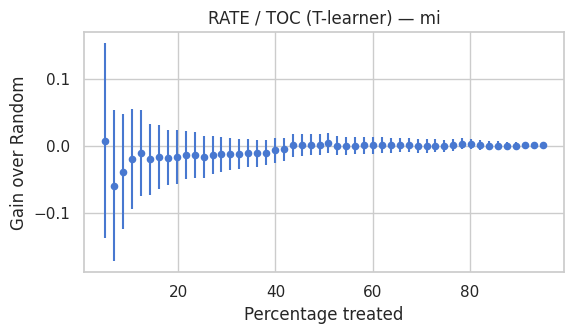

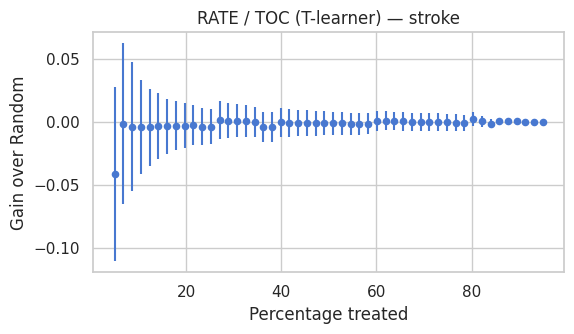

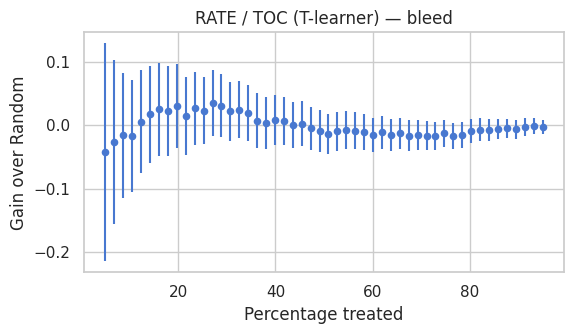

In [4]:
from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from lightgbm import LGBMRegressor
from econml.validate import DRTester

# Treatment arm (1 = prolonged/lDAPT, 0 = abbreviated/sDAPT) for the DR validation.
T = X['regimen'].map({'prolonged DAPT': 1, 'abbreviated DAPT': 0}).to_numpy()
FEATURE_COLS = X_num.columns


class TLearnerEffect:
    """Exposes .effect(X) = P(event | lDAPT, x) - P(event | sDAPT, x) for one
    endpoint, so econml's DRTester can validate the T-learner CATE with exactly
    the same doubly-robust protocol used for the causal forest (notebook 07)."""

    def __init__(self, pipe_l, pipe_s, target_idx, feature_cols):
        self.pipe_l, self.pipe_s = pipe_l, pipe_s
        self.target_idx, self.feature_cols = target_idx, feature_cols

    def effect(self, X, T0=0, T1=1):
        Xdf = X if isinstance(X, pd.DataFrame) else pd.DataFrame(X, columns=self.feature_cols)
        risk_l = predict_proba_matrix(self.pipe_l, Xdf)[:, self.target_idx]
        risk_s = predict_proba_matrix(self.pipe_s, Xdf)[:, self.target_idx]
        return risk_l - risk_s


# Honest split: refit each arm on 70% (clone keeps the tuned params) and validate
# the CATE out-of-sample on the held-out 30% the models never saw.
tr_idx, va_idx = train_test_split(
    np.arange(len(X_num)), test_size=0.3, random_state=42, stratify=T)
Xtr, Xva = X_num.iloc[tr_idx], X_num.iloc[va_idx]
Ttr, Tva = T[tr_idx], T[va_idx]
Ytr, Yva = y_df.iloc[tr_idx], y_df.iloc[va_idx]

pipe_l_tr = clone(pipe_l).fit(Xtr[Ttr == 1], Ytr[Ttr == 1])   # prolonged-DAPT arm
pipe_s_tr = clone(pipe_s).fit(Xtr[Ttr == 0], Ytr[Ttr == 0])   # abbreviated-DAPT arm

rows, het_results = [], {}
for i, label in enumerate(TARGET_LABELS):
    tester = DRTester(
        model_regression=LGBMRegressor(n_estimators=100, max_depth=4, random_state=42, verbose=-1),
        model_propensity=DummyClassifier(strategy='prior'),   # RCT: known constant propensity
        cate=TLearnerEffect(pipe_l_tr, pipe_s_tr, i, FEATURE_COLS), cv=3,
    )
    tester.fit_nuisance(Xva.values, Tva, Yva.iloc[:, i].values,
                        Xtr.values, Ttr, Ytr.iloc[:, i].values)
    het_results[label] = tester.evaluate_all(Xva.values, Xtr.values)
    s = het_results[label].summary().iloc[0]
    rows.append({
        'endpoint': label,
        'BLP_slope': s['blp_est'], 'BLP_p': s['blp_pval'],
        'RATE_AUTOC': s['autoc_est'], 'AUTOC_p': s['autoc_pval'],
        'QINI': s['qini_est'], 'QINI_p': s['qini_pval'],
        'cal_R2': s['cal_r_squared'],
    })

het = pd.DataFrame(rows).set_index('endpoint')
print('T-learner heterogeneity validation on held-out 30% '
      '(positive estimate with small p ==> real, usable heterogeneity)')
print(het.round(3))

# RATE / TOC curve per endpoint: average effect among the top-ranked patients as we
# treat from highest predicted CATE downward (same diagnostic as the causal forest).
for label in TARGET_LABELS:
    ax = het_results[label].plot_toc(1)
    ax.set_title(f'RATE / TOC (T-learner) — {label}')
    ax.figure.set_size_inches(6, 3.5)
    plt.tight_layout()
    plt.show()


## CATE distributions per target

One KDE panel per endpoint, `NCOLS` per row. Red dashed line = no effect (CATE = 0); black
line = mean CATE.

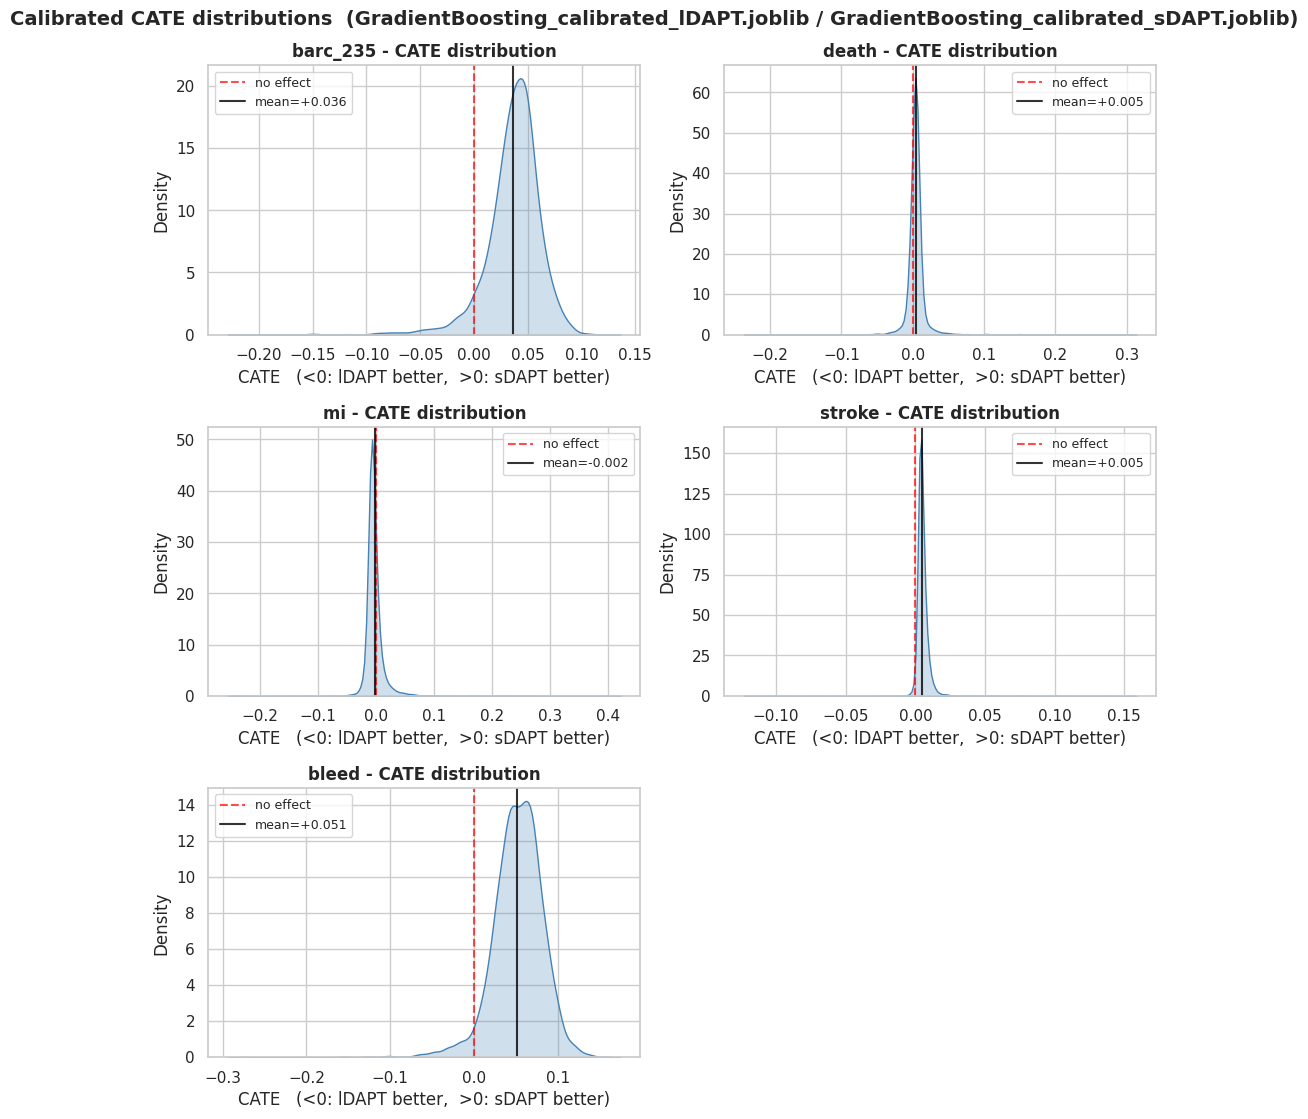

In [5]:
def target_grid(ncols, figsize_per=(5.2, 3.8)):
    # Axes grid with one cell per target, extra cells hidden.
    n = len(TARGET_LABELS)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize_per[0] * ncols, figsize_per[1] * nrows),
        squeeze=False,
    )
    axes = axes.ravel()
    for ax in axes[n:]:
        ax.set_visible(False)
    return fig, axes


fig, axes = target_grid(NCOLS)
for ax, label in zip(axes, TARGET_LABELS):
    sns.kdeplot(cate[label], ax=ax, fill=True, color='steelblue')
    ax.axvline(0, color='red', linestyle='--', alpha=0.7, label='no effect')
    ax.axvline(cate[label].mean(), color='black', linestyle='-', alpha=0.8,
               label=f'mean={cate[label].mean():+.3f}')
    ax.set_title(f'{label} - CATE distribution', fontweight='bold')
    ax.set_xlabel('CATE   (<0: lDAPT better,  >0: sDAPT better)')
    ax.legend(fontsize=9)
fig.suptitle(f'Calibrated CATE distributions  ({name_l} / {name_s})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Sorted CATE (uplift curves)

Patients sorted by CATE: green marks those predicted to do better on lDAPT (CATE < 0),
orange those predicted to do better on sDAPT (CATE > 0).

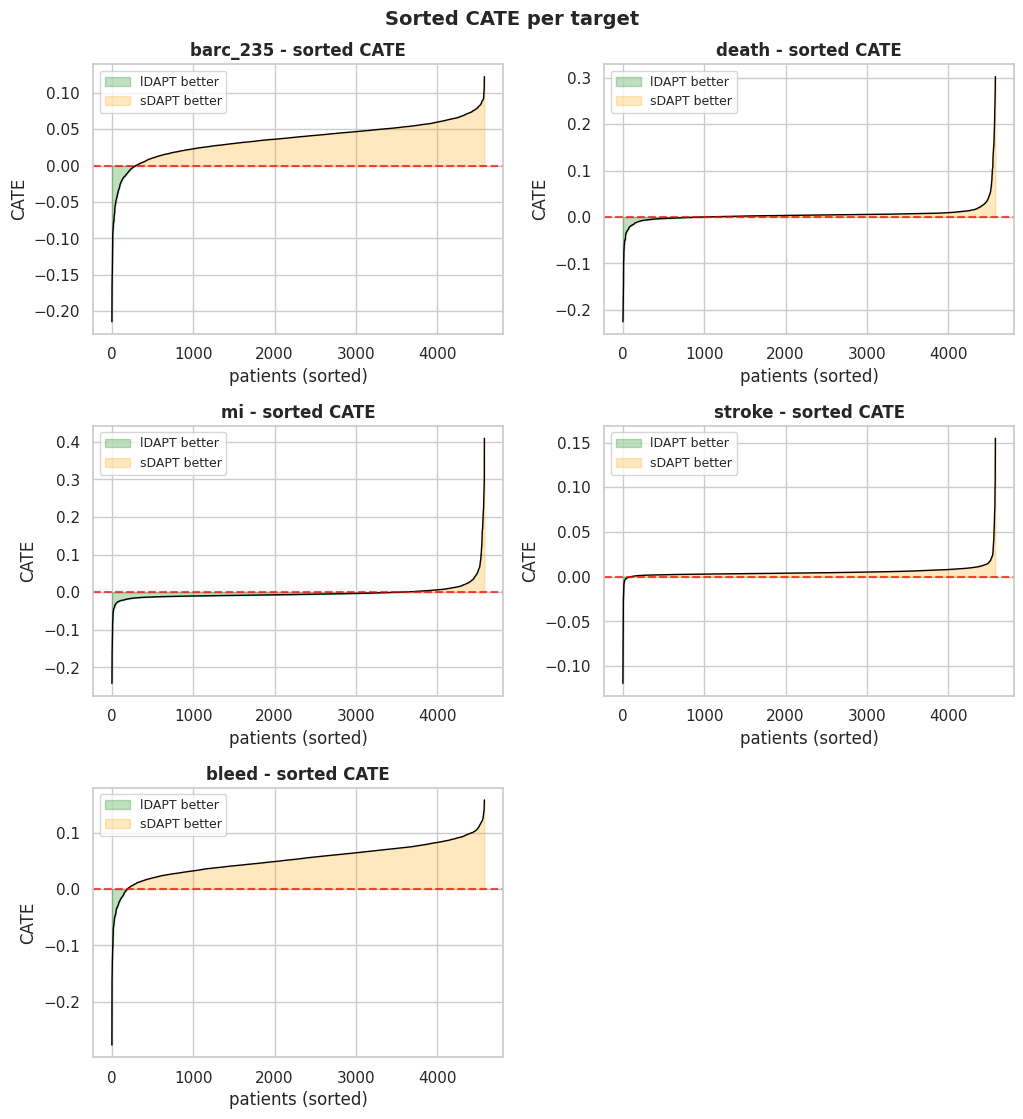

In [6]:
fig, axes = target_grid(NCOLS)
for ax, label in zip(axes, TARGET_LABELS):
    ordered = np.sort(cate[label].to_numpy())
    xs = np.arange(len(ordered))
    ax.plot(xs, ordered, linewidth=1.0, color='black')
    ax.axhline(0, color='red', linestyle='--', alpha=0.7)
    ax.fill_between(xs, ordered, 0, where=ordered < 0, color='green', alpha=0.25,
                    label='lDAPT better')
    ax.fill_between(xs, ordered, 0, where=ordered > 0, color='orange', alpha=0.25,
                    label='sDAPT better')
    ax.set_title(f'{label} - sorted CATE', fontweight='bold')
    ax.set_xlabel('patients (sorted)')
    ax.set_ylabel('CATE')
    ax.legend(fontsize=9, loc='upper left')
fig.suptitle('Sorted CATE per target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()